**８　銀行ビジネスモデルと教師なし学習：クラスター分析**

　主成分分析とともに、多変量解析のひとつとして「分類」に用いられる手法がクラスター分析です。このクラスター分析も、被説明変数を説明変数により説明する統計分析ではなく、大規模データの要約に用いられます。
　クラスター分析は、階層クラスター分析と非階層クラスター分析の2種類があります。階層クラスター分析では、多くの場合、デンドログラムと呼ばれる階層樹形図を作成し、それぞれのクラスターがどの程度、似通っているのか、はたまた全く異なる特徴を持つのかを視覚的に理解することができます。これに対して非階層クラスター分析は、予めクラスター数を定めた上で、それぞれの標本がどの　クラスターに属するのかを解釈することができます。階層クラスター分析は標本数が100サンプル未満のデータに用いることが多く、非階層クラスター分析は10,000万サンプルを超えるビッグデータに用いられます。それゆえ、ファイナンス分析の世界では、前者は競合他社の分析や、顧客企業の競争戦略分析などB to Bのデータサイエンスとして用いられることが多く、後者は数十万件の個人データを用いるB to Cの個人マーケット分析に用いられます。


　本例では、教師なし学習手法である、階層クラスター分析を用いて、10種類の銀行財務指標から少数のクラスターへ次元削減します。そしてこれらの3～4つのクラスターが、どのような特徴を反映しているかを定義した上で、どの銀行がいかなる財務上の特徴を持つ集合に属するのか、すなわち、どの銀行がいかなる銀行ビジネスモデルを持つのかを分析する事例を示します。本例では、全国銀行協会加盟行のうち、都市銀行、地方銀行他69銀行の単体決算データの10種類の財務指標を用いて、クラスター分析を行い、どの銀行がどのようなビジネスモデルを有するのかについての分析事例を示します。

　この実装を始めるに際し、まずはじめにmatplotlibで日本語表記による可視化のためのパッケージjapanize-matplotlibをインストールします。

In [ ]:
pip install japanize-matplotlib

　続いて、統計分析と数値計算のためのpandasとnumpy、グラフ作成のためのmatplotlib、そして階層クラスター分析のためのscipy.cluster.hierarchyから3つのライブラリ、距離計算のためにscipy.spatialからdistanceをインポートします。

In [2]:
#[1]ライブラリの読み込み
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial import distance

　次に前もってオンライン・ストレージに保存した全国銀行協会の銀行データを読み込みます。セル[2]の2行目では、読み込んだCSVデータをpandasデータフレーム形式でdataというデータフレーム名で格納します。3行目ではこのデータフレイムの最左列”id”の銀行名をインデックス化します。このインデックス化を行うことで、後にデンドログラム描画の際に、わざわざ銀行名をひとつずつ記述する手間が省けます。

In [ ]:
#[2]銀行財務データの読み込み
url = "https://github.com/nagamamo/data/blob/main/8_bank_financial_data.csv?raw=true"#Git-hubからCSVデータの入手
data = pd.read_csv(url, encoding='shift_jis')#データフレームの作成
df = data.set_index("id")#証券コードをインデックスへ変更
df2 = df.dropna()
df2.head()

　続いて、データを標準化します。それぞれ単位が異なるデータを扱う際には、標準化もしくは正規化を行う必要があります。標準化は各列のデータを平均0、標準偏差1に変換する作業で、正規化は最小値0、最大値1に変換する作業です。本例では標準化を選択します。この結果、下図の通り、全変数が標準偏差「1」に変換されていることがわかります。

In [ ]:
#[3]データ前処理
df3 = df2.select_dtypes(include=np.number) #数値データのスクリーニング
df = (df3 - df3.mean()) / df3.std() #データ標準化
df.describe() #記述統計の表示

　最後にウォード法によりユークリッド距離を算出して、デンドログラムを描画します。セル[4]ではこれらの手法を指定してデータフレームZに格納し、セル[5]ではデンドログラムの図表の大きさを設定します。セル[4]～[6]の実行により、デンドログラムが導出できます。このデンドログラムは距離が近い順から並べられているため、隣に表記されている銀行が基本的には、10個の財務指標の距離が近い銀行です。

In [5]:
#[4]銀行財務データのクラスタリング
Z = linkage(df, method = "ward", metric = "euclidean") #ウォード法・ユークリッド距離による算出

In [6]:
#[5]デンドログラムの図表設定
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

　埼玉りそな銀行とセブン銀行のように、三井住友銀行やみずほ銀行などのメガバンクの隣に記述されていても、ユークリッド距離が大きくかけ離れている銀行があることに注意が必要です。すなわちどのクラスターにも属さず、それ自身がひとつのクラスターを形成している属性（銀行）もあります。

Text(0.5, 0, 'ユークリッド距離')

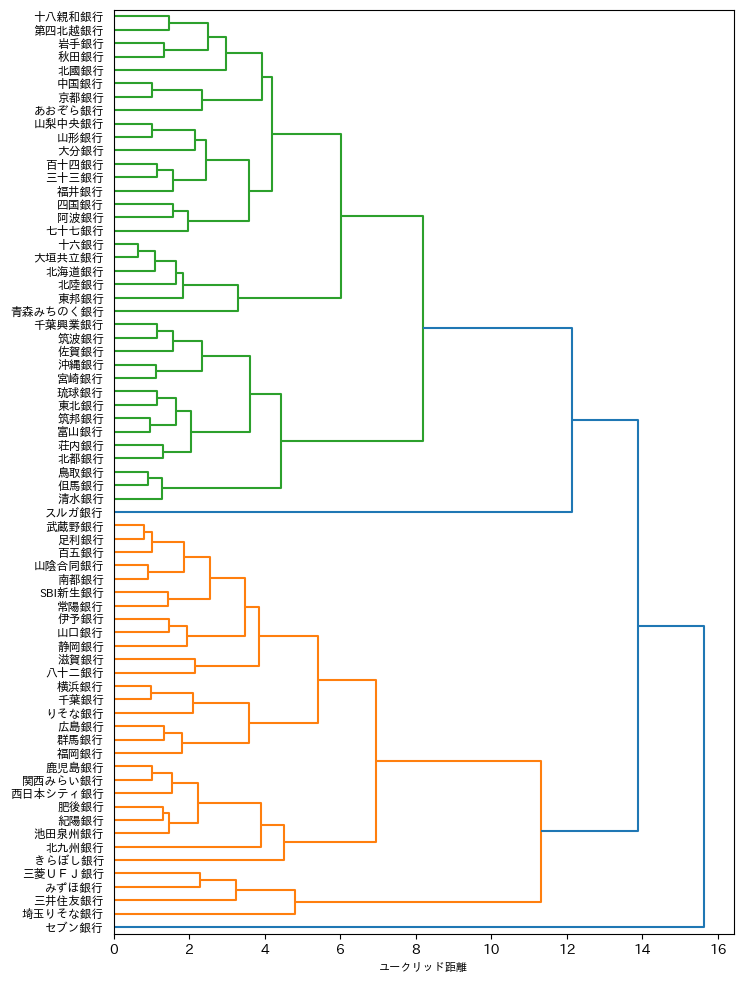

In [7]:
#[6]デンドログラムの描画
ax = plt.figure(figsize=(8,12)).gca()
dendrogram(Z,labels=df.index,orientation = 'right',color_threshold =12)
bounds = ax.get_xbound()
plt.xticks(fontsize=10)
plt.yticks(fontsize=8.5)
plt.xlabel("ユークリッド距離",fontsize=8)

　以下は、この階層樹形図から銀行ビジネスモデルをどのように解釈するかについての一例です。まずユークリッド距離5.0を臨界点とすると、図表の上から十八親和銀行から七十七銀行のクラスター1、十六銀行から青森みちのく銀行のクラスター2、千葉興業銀行から清水銀行のクラスター3、武蔵野銀行から八十二銀行のクラスター4、横浜銀行から福岡銀行からのクラスター5、メガバンクのクラスター6、その他のクラスターの7クラスターに分類可能です。これらのクラスターは預貸率が高く地元の資金需要が大きいクラスターと、地元に資金需要がなく預証率が高いクラスター、そしてその中で預貸金利鞘、総資金利鞘の高低が影響を与えています。不良債権比率が高い銀行、自己資本比率が低い銀行はまた異なるクラスターに分類されています。クラスター5は地元に旺盛な資金需要がある大規模地方銀行であり、クラスター6は総資産規模、ROE、ROAが高位な銀行です。



In [ ]:
#[7]距離行列の表示
dist_matrix = distance.pdist(df, metric='euclidean')#ユークリッド距離の計算
labels = df.index#対称行列に変換して表示
dist_df = pd.DataFrame(distance.squareform(dist_matrix), columns=labels, index=labels)
print(dist_df)